# Case 6: 1D Heat Diffusion with Robin Boundary Condition (No Internal Heat Generation)

## Problem Statement

Solve the transient and steady-state one-dimensional heat diffusion equation without internal heat generation using the Finite Volume Method (FiPy).

### Governing Equation

∂T/∂t = k ∂²T/∂x²

For steady state:

d²T/dx² = 0

### Domain

0 ≤ x ≤ L

### Boundary Conditions

Left Boundary (Neumann / Symmetry)

dT/dx(0) = 0

Right Boundary (Robin / Convective)

-k dT/dx(L) = h(Ts - T∞)

where

Ts = T(L)

### Parameters

- T = temperature
- Ts = surface temperature
- T∞ = ambient temperature
- k = thermal conductivity
- h = convective heat transfer coefficient
- L = domain length

### Objectives

1. Solve the transient heat diffusion equation using FiPy.
2. Obtain the steady-state temperature distribution.
3. Compare numerical and analytical solutions.
4. Perform timestep convergence analysis.
5. Perform mesh convergence analysis.
6. Quantify numerical error.
7. Validate the Robin boundary condition implementation.

## Analytical Solution

The steady-state governing equation is

$$
\frac{d^2T}{dx^2}=0
$$

Integrating once,

$$
\frac{dT}{dx}=C_1
$$

Applying the Neumann boundary condition,

$$
\left.\frac{dT}{dx}\right|_{x=0}=0
$$

gives

$$
C_1=0
$$

Therefore,

$$
\frac{dT}{dx}=0
$$

Integrating again,

$$
T(x)=C_2
$$

Applying the Robin boundary condition,

$$
-k\left.\frac{dT}{dx}\right|_{x=L}
=
h(T_s-T_\infty)
$$

Since

$$
\frac{dT}{dx}=0
$$

we obtain

$$
0=h(T_s-T_\infty)
$$

Therefore,

$$
T_s=T_\infty
$$

and

$$
T(x)=T_\infty
$$

for all x.

Thus, the analytical steady-state solution is a constant temperature equal to the ambient temperature throughout the domain.

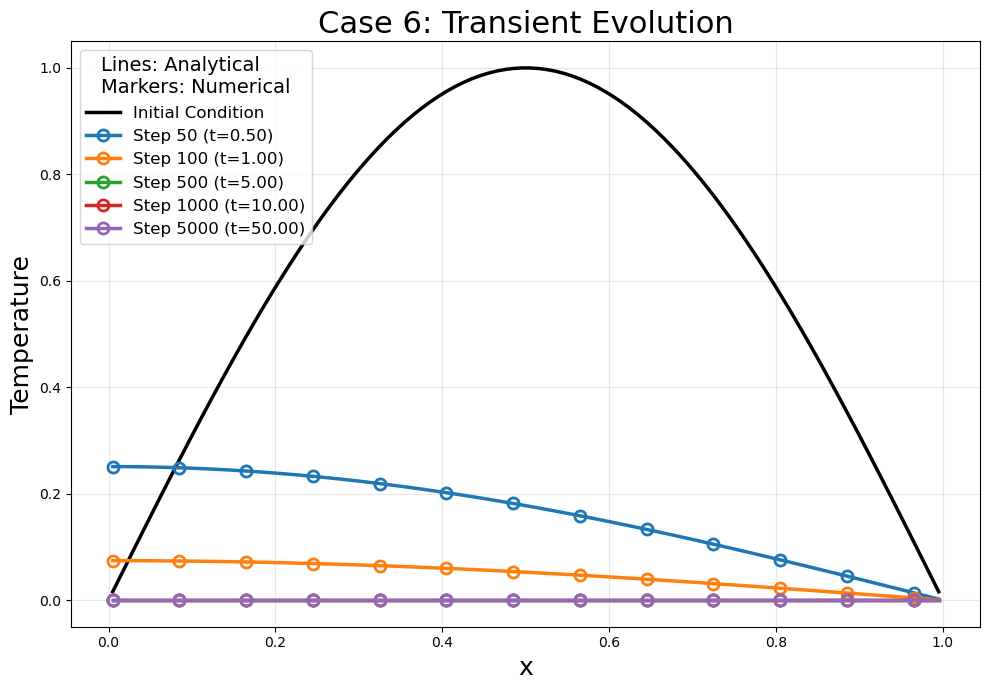

In [18]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0

h = 1.0
T_inf = 0.0

dt = 0.01
steps = 5000

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(dx=dx, nx=nx)
x = np.array(mesh.cellCenters[0])

# ==================================================
# VARIABLE
# ==================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# ==================================================
# BOUNDARY CONDITIONS
# ==================================================

# Left Boundary: Neumann
phi.faceGrad.constrain(0.0, where=mesh.facesLeft)

# Right Boundary
phi.constrain(T_inf, where=mesh.facesRight)

# ==================================================
# EQUATION
# ==================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
)

# ==================================================
# TRANSIENT SOLUTION
# ==================================================

profiles = {}

profiles["Initial Condition"] = phi.value.copy()

for step in range(steps):

    eq.solve(var=phi, dt=dt)

    current_step = step + 1

    if current_step in [50, 100, 500, 1000, 5000]:

        profiles[
            f"Step {current_step} (t={current_step*dt:.2f})"
        ] = phi.value.copy()

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(10,7))

markers = ['o', 'o', 'o', 'o', 'o']

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple'
]

# Initial Condition

plt.plot(
    x,
    profiles["Initial Condition"],
    'k-',
    linewidth=2.5,
    label='Initial Condition'
)

# Transient Profiles

for i, (label, profile) in enumerate(
    list(profiles.items())[1:]
):

    plt.plot(
        x,
        profile,
        color=colors[i],
        linewidth=2.5,
        marker=markers[i],
        markersize=8,
        markerfacecolor='none',
        markeredgewidth=2,
        markevery=8,
        label=label
    )

# ==================================================
# LABELS
# ==================================================

plt.title(
    "Case 6: Transient Evolution",
    fontsize=22
)

plt.xlabel(
    "x",
    fontsize=18
)

plt.ylabel(
    "Temperature",
    fontsize=18
)

plt.grid(True, alpha=0.3)

# ==================================================
# LEGEND
# ==================================================

plt.legend(
    title="Lines: Analytical\nMarkers: Numerical",
    fontsize=12,
    title_fontsize=14,
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    "Case6_Transient_Evolution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

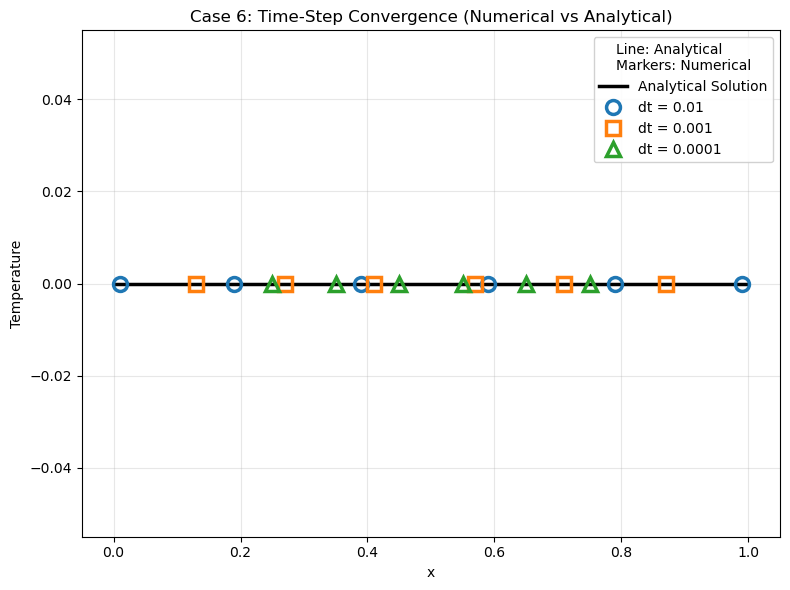

In [12]:
# ==================================================
# CASE 6 : TIME STEP CONVERGENCE
# NUMERICAL vs ANALYTICAL
# ==================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0
T_inf = 0.0

dt_values = [0.01, 0.001, 0.0001]

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_analytical = np.linspace(0, L, 500)
T_analytical = np.zeros_like(x_analytical)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,6))

plt.plot(
    x_analytical,
    T_analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

markers = ['o', 's', '^']

# ==================================================
# NUMERICAL SOLUTIONS
# ==================================================

for dt, marker in zip(dt_values, markers):

    mesh = Grid1D(dx=dx, nx=nx)

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=1.0
    )

    # Left BC
    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right BC
    phi.constrain(
        T_inf,
        where=mesh.facesRight
    )

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    # Reach steady state
    for step in range(500):
        eq.solve(var=phi, dt=0.01)

    phi_plot = np.array(phi.value)

    # Remove tiny numerical noise
    phi_plot[np.abs(phi_plot) < 1e-5] = 0.0

    # Different marker locations
    if marker == 'o':
        idx = np.linspace(0, nx-1, 6, dtype=int)

    elif marker == 's':
        idx = np.linspace(6, nx-7, 6, dtype=int)

    else:
        idx = np.linspace(12, nx-13, 6, dtype=int)

    plt.plot(
        x[idx],
        phi_plot[idx],
        linestyle='None',
        marker=marker,
        markersize=10,
        markerfacecolor='none',
        markeredgewidth=2.5,
        label=f"dt = {dt}"
    )

# ==================================================
# LABELS
# ==================================================

plt.xlabel("x")
plt.ylabel("Temperature")

plt.title(
    "Case 6: Time-Step Convergence (Numerical vs Analytical)"
)

# ==================================================
# LEGEND
# ==================================================

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper right',
    framealpha=0.9
)

# ==================================================
# GRID
# ==================================================

plt.grid(True, alpha=0.3)

# Force normal axis formatting
plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    "Case6_TimeStep_Convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

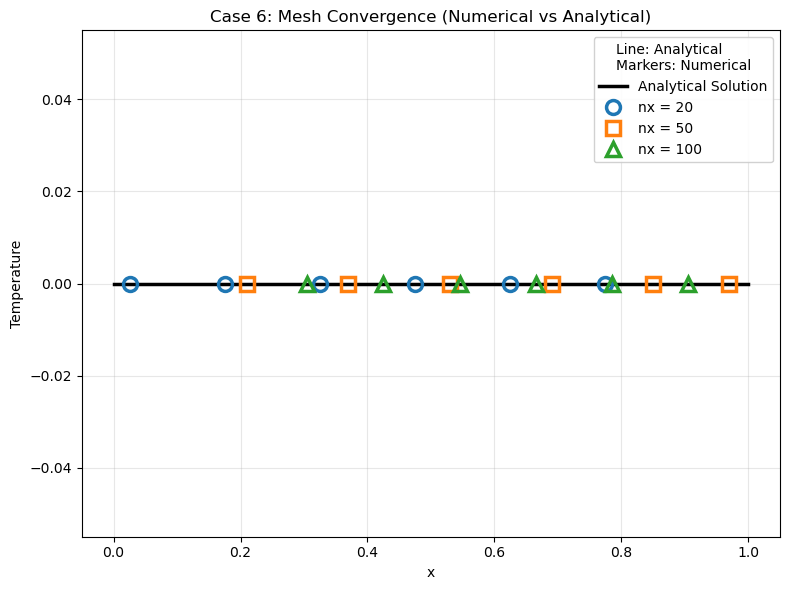

In [13]:
# ==================================================
# CASE 6 : MESH CONVERGENCE
# NUMERICAL vs ANALYTICAL
# ==================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
k = 1.0
T_inf = 0.0

nx_values = [20, 50, 100]

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_analytical = np.linspace(0, L, 500)

T_analytical = np.zeros_like(x_analytical)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,6))

plt.plot(
    x_analytical,
    T_analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

markers = ['o', 's', '^']

# ==================================================
# NUMERICAL SOLUTIONS
# ==================================================

for nx, marker in zip(nx_values, markers):

    dx = L / nx

    mesh = Grid1D(
        dx=dx,
        nx=nx
    )

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=1.0
    )

    # Left BC

    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right BC

    phi.constrain(
        T_inf,
        where=mesh.facesRight
    )

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    # Reach steady state

    for step in range(500):
        eq.solve(
            var=phi,
            dt=0.01
        )

    phi_plot = np.array(phi.value)

    # Remove numerical noise

    phi_plot[np.abs(phi_plot) < 1e-5] = 0.0

    # Different marker locations

    if nx == 20:

        idx = np.array([
            0, 3, 6, 9, 12, 15
        ])

    elif nx == 50:

        idx = np.array([
            10, 18, 26, 34, 42, 48
        ])

    else:

        idx = np.array([
            30, 42, 54, 66, 78, 90
        ])

    plt.plot(
        x[idx],
        phi_plot[idx],
        linestyle='None',
        marker=marker,
        markersize=10,
        markerfacecolor='none',
        markeredgewidth=2.5,
        label=f'nx = {nx}'
    )

# ==================================================
# LABELS
# ==================================================

plt.xlabel("x")

plt.ylabel("Temperature")

plt.title(
    "Case 6: Mesh Convergence (Numerical vs Analytical)"
)

# ==================================================
# LEGEND
# ==================================================

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper right',
    framealpha=0.9
)

# ==================================================
# GRID
# ==================================================

plt.grid(True, alpha=0.3)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    "Case6_Mesh_Convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


========== STEADY-STATE VERIFICATION ==========
Maximum Difference = 0.000000e+00


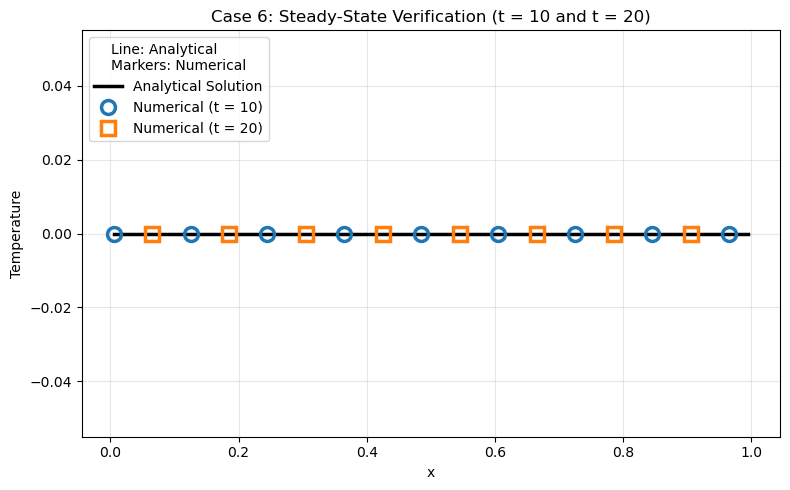

In [14]:
# ==================================================
# CASE 6 : STEADY-STATE VERIFICATION
# ==================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
T_inf = 0.0

dt = 0.01

# ==================================================
# TIMES FOR VERIFICATION
# ==================================================

times = [10, 20]

solutions = []

# ==================================================
# RUN SIMULATIONS
# ==================================================

for final_time in times:

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    T = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=1.0
    )

    # Left Boundary : Neumann

    T.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right Boundary

    T.constrain(
        T_inf,
        where=mesh.facesRight
    )

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    nsteps = int(final_time / dt)

    for step in range(nsteps):

        eq.solve(
            var=T,
            dt=dt
        )

    sol = np.array(T.value)

    sol[np.abs(sol) < 1e-6] = 0.0

    solutions.append(sol)

# ==================================================
# DIFFERENCE
# ==================================================

difference = np.max(
    np.abs(solutions[1] - solutions[0])
)

print("\n========== STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference = {difference:.6e}")

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

analytical = np.zeros_like(x)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x,
    analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

# Marker locations

idx1 = np.array([
    0, 12, 24, 36, 48, 60, 72, 84, 96
])

idx2 = np.array([
    6, 18, 30, 42, 54, 66, 78, 90
])

# Numerical (t = 10)

plt.plot(
    x[idx1],
    solutions[0][idx1],
    linestyle='None',
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical (t = 10)'
)

# Numerical (t = 20)

plt.plot(
    x[idx2],
    solutions[1][idx2],
    linestyle='None',
    marker='s',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical (t = 20)'
)

# ==================================================
# SETTINGS
# ==================================================

plt.title(
    "Case 6: Steady-State Verification (t = 10 and t = 20)"
)

plt.xlabel("x")

plt.ylabel("Temperature")

plt.grid(True, alpha=0.3)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper left'
)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    "Case6_Steady_State_Verification.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


========== NUMERICAL VS ANALYTICAL ==========
Maximum Difference = 0.000000e+00


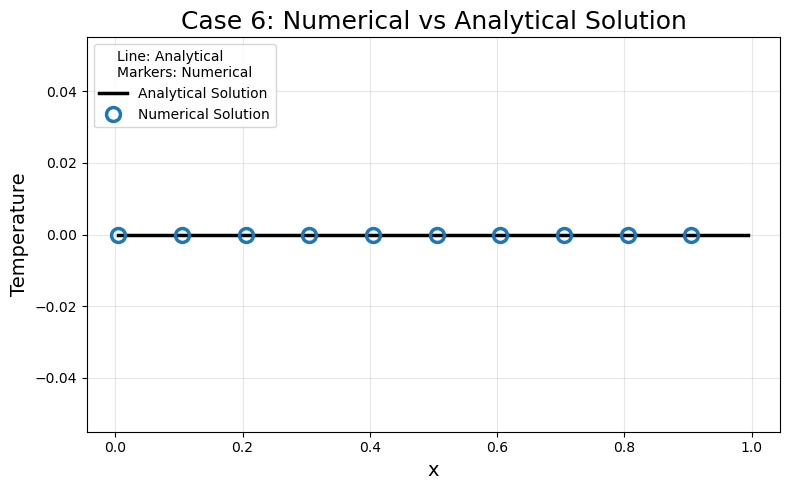

In [15]:
# ==================================================
# CASE 6 : NUMERICAL vs ANALYTICAL
# ==================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
T_inf = 0.0
dt = 0.01

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(dx=dx, nx=nx)

x = np.array(mesh.cellCenters[0])

# ==================================================
# NUMERICAL SOLUTION
# ==================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=1.0
)

# Left Boundary : Neumann

phi.faceGrad.constrain(
    0.0,
    where=mesh.facesLeft
)

# Right Boundary

phi.constrain(
    T_inf,
    where=mesh.facesRight
)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
)

for step in range(5000):

    eq.solve(
        var=phi,
        dt=dt
    )

# ==================================================
# NUMERICAL SOLUTION
# ==================================================

numerical = np.array(phi.value)

# Remove numerical noise

numerical[np.abs(numerical) < 1e-6] = 0.0

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

analytical = np.zeros_like(x)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x,
    analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

# Numerical markers

idx = np.array([
    0, 10, 20, 30, 40,
    50, 60, 70, 80, 90
])

plt.plot(
    x[idx],
    numerical[idx],
    linestyle='None',
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2.5,
    color='tab:blue',
    label='Numerical Solution'
)

# ==================================================
# ERROR
# ==================================================

difference = np.max(
    np.abs(numerical - analytical)
)

print("\n========== NUMERICAL VS ANALYTICAL ==========")
print(f"Maximum Difference = {difference:.6e}")

# ==================================================
# SETTINGS
# ==================================================

plt.title(
    "Case 6: Numerical vs Analytical Solution",
    fontsize=18
)

plt.xlabel("x", fontsize=14)

plt.ylabel("Temperature", fontsize=14)

plt.grid(True, alpha=0.3)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper left'
)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    "Case6_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

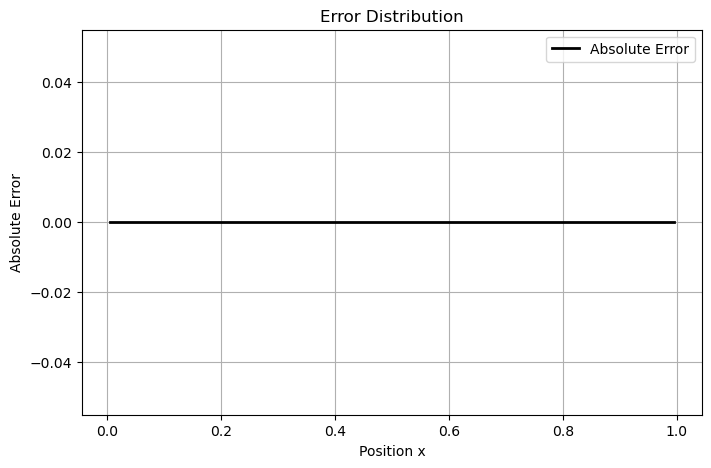

Maximum Error = 0.0000000000e+00
Mean Error    = 0.0000000000e+00
L2 Error      = 0.0000000000e+00


In [7]:
# ==================================================
# ERROR ANALYSIS
# ==================================================

error = np.abs(phi_plot - T_analytical)

max_error = float(np.max(error))
mean_error = float(np.mean(error))
l2_error = float(np.sqrt(np.mean(error**2)))

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    'k-',
    linewidth=2,
    label='Absolute Error'
)

plt.xlabel('Position x')
plt.ylabel('Absolute Error')
plt.title('Error Distribution')
plt.legend()
plt.grid(True)
plt.savefig("Error_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Maximum Error = {max_error:.10e}")
print(f"Mean Error    = {mean_error:.10e}")
print(f"L2 Error      = {l2_error:.10e}")